In [ ]:
# My plan is, to do the EDA and then feature engineering and then clustering and then visualize. Here, I can look at the data and find out stuff.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
flights = pd.read_csv('raw_data/flights_filtered.csv')
hotels = pd.read_csv('raw_data/hotels_filtered.csv')
users = pd.read_csv('raw_data/Users_filtered.csv')
sessions= pd.read_csv('raw_data/Sessions_filtered.csv')

In [5]:
sessions.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,167852-c8b94dadc94c4f6889c506635eabcae5,167852,NaN,2022-05-03 08:20:00,2022-05-03 08:21:15,True,True,0.05,0.10,False,False,10,False
1,101961-90b0b37c3d3d4676b2a62d6485e02935,101961,NaN,2022-05-09 18:14:00,2022-05-09 18:17:08,False,False,NaN,NaN,False,False,25,False
2,174997-8a2be403095348558385433f288d6440,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2022-05-10 20:16:00,2022-05-10 20:17:50,False,True,NaN,0.05,True,False,15,False
3,106907-4c1f7d4d0a6b4d7f874ab0012f5673e7,106907,NaN,2022-05-13 14:25:00,2022-05-13 14:29:14,False,False,NaN,NaN,False,False,34,False
4,181157-7279cbcf6b5f4396b2b22cd59741e7c3,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-15 20:13:00,2022-05-15 20:16:04,False,False,NaN,NaN,True,True,25,False


In [4]:
sessions[~(~sessions[["flight_discount_amount", "hotel_discount_amount"]].isna().values == sessions[["flight_discount", "hotel_discount"]].values).all(axis=1)]

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
23906,101486-46912e06b8f94b949f46af20eb097f8f,101486,101486-29a51199b1a748da8c45d3d2fc9c691a,2022-03-26 20:08:22,2022-03-26 22:08:22,True,True,NaN,NaN,True,True,156,True
23907,118043-e476985728a741d7a96ea1dcf55963e6,118043,118043-2c1b2e17eb1147e184b00be13725d0fd,2022-04-22 09:38:27,2022-04-22 10:04:44.411729,True,True,NaN,NaN,True,True,26,True
23908,153982-0a2c4b9c37594cca8019068acedd878a,153982,153982-5ee3beaabece462ba68982ef4f8e3a23,2022-07-08 13:15:40,2022-07-08 14:20:35.612564,True,True,NaN,NaN,True,True,64,True
23909,174997-d37e4081489646fc891296f5e21b96f1,174997,174997-a7c3a96620594e849a2345ac4e0bd45d,2023-01-05 20:17:50,2023-01-05 22:17:50,True,True,NaN,NaN,True,True,155,True
23910,181157-4689176bf8e2444f928c77739c75c713,181157,181157-259acaefcd924050bd6640f049eded1a,2022-05-23 20:16:04,2022-05-23 22:16:04,True,True,NaN,NaN,True,True,200,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48673,694265-74b2a86e73854afea04cd84b1a1d10e3,694265,694265-442d6499b511481786add276f620d4fc,2023-07-26 21:37:49,2023-07-26 22:30:14.467636,True,True,NaN,NaN,True,True,52,True
48674,589228-c82de5b13d8d4739aeb90e2ca924d2e0,589228,589228-7cbd8bd73eed4c549a0074919e71fdc8,2023-07-20 21:01:17,2023-07-20 21:45:04.905844,True,True,NaN,NaN,True,True,43,True
48675,671151-fa865fb0bf8249aeb164408b470322d2,671151,671151-a25acb9062764a168fbd4286d15d57fd,2023-07-24 17:45:47,2023-07-24 18:09:14.839854,True,True,NaN,NaN,True,True,23,True
48676,609393-17fa2042385e48faac6ab20586749340,609393,609393-b92d487037ec447db1e3ddf977709a52,2023-07-21 21:02:05,2023-07-21 21:27:18.179946,True,True,NaN,NaN,True,True,25,True


- deleting columns hotel/flight_discount, because the information is already in the amount section?
→ Error in the data: there are rows, that say, there are discounts, but there is no amount
→ assumption: error in amount, not in True/False column. So I am filling in the False NaN values with the mean # TODO

In [6]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 48683 entries, 0 to 48682
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              48683 non-null  str    
 1   user_id                 48683 non-null  int64  
 2   trip_id                 16778 non-null  str    
 3   session_start           48683 non-null  str    
 4   session_end             48683 non-null  str    
 5   flight_discount         48683 non-null  bool   
 6   hotel_discount          48683 non-null  bool   
 7   flight_discount_amount  8170 non-null   float64
 8   hotel_discount_amount   6183 non-null   float64
 9   flight_booked           48683 non-null  bool   
 10  hotel_booked            48683 non-null  bool   
 11  page_clicks             48683 non-null  int64  
 12  cancellation            48683 non-null  bool   
dtypes: bool(5), float64(2), int64(2), str(4)
memory usage: 3.2 MB


Dtypes seem correct, but not session start/end. I would change that #TODO

In [8]:
sessions[["flight_discount_amount", "hotel_discount_amount"]].mean()

flight_discount_amount    0.139553
hotel_discount_amount     0.112065
dtype: float64

In [ ]:
#clicks per customer per session or per booking
#trips per user
# how many sessions per trip per user

<Axes: >

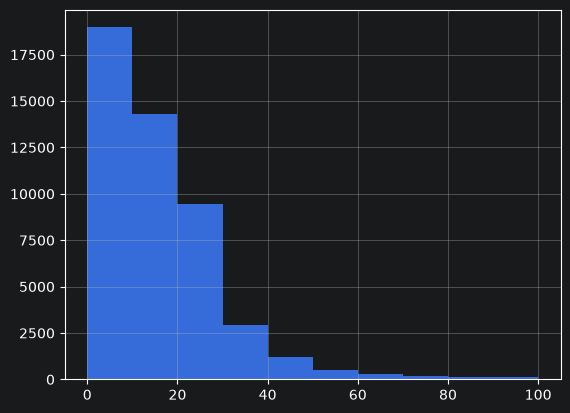

In [15]:
sessions['page_clicks'].hist(range=[0,100])

with a few hundred outliers above 100